In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
df=pd.read_csv("./data (1).csv", encoding="latin1")
df

,Duration,Date,Pulse,Maxpulse,Calories
0,60,'2020/12/01',110,130,409.1
1,60,'2020/12/02',117,145,479.0
2,60,'2020/12/03',103,135,340.0
3,45,'2020/12/04',109,175,282.4
4,45,'2020/12/05',117,148,406.0
5,60,'2020/12/06',102,127,300.0
6,60,'2020/12/07',110,136,374.0
7,450,'2020/12/08',104,134,253.3
8,30,'2020/12/09',109,133,195.1
9,60,'2020/12/10',98,124,269.0


In [40]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

1


In [41]:
print(df.columns)


Index(['Duration', 'Date', 'Pulse', 'Maxpulse', 'Calories'], dtype='object')


In [42]:
df.isna().sum()

Duration    0
Date        1
Pulse       0
Maxpulse    0
Calories    2
dtype: int64

In [43]:
df.dropna(subset=['Calories'], inplace=True)
df.to_csv('data.csv', index=False)

In [44]:
df['Date'] = df['Date'].replace({'nan': None, 'None': None, '': None})

In [45]:
df['Date'] = (
    df['Date'].astype(str).str.replace("'", '', regex=False).str.strip()
)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', format='mixed')
df['Date'] = df['Date'].dt.strftime('%Y/%m/%d')
df['Date'] = df['Date'].where(df['Date'].notna(), None)
df.to_csv('data.csv', index=False)

In [47]:
df

,Duration,Date,Pulse,Maxpulse,Calories
0,60,2020/12/01,110,130,409.1
1,60,2020/12/02,117,145,479.0
2,60,2020/12/03,103,135,340.0
3,45,2020/12/04,109,175,282.4
4,45,2020/12/05,117,148,406.0
5,60,2020/12/06,102,127,300.0
6,60,2020/12/07,110,136,374.0
7,450,2020/12/08,104,134,253.3
8,30,2020/12/09,109,133,195.1
9,60,2020/12/10,98,124,269.0


In [49]:
df.shape


(29, 5)

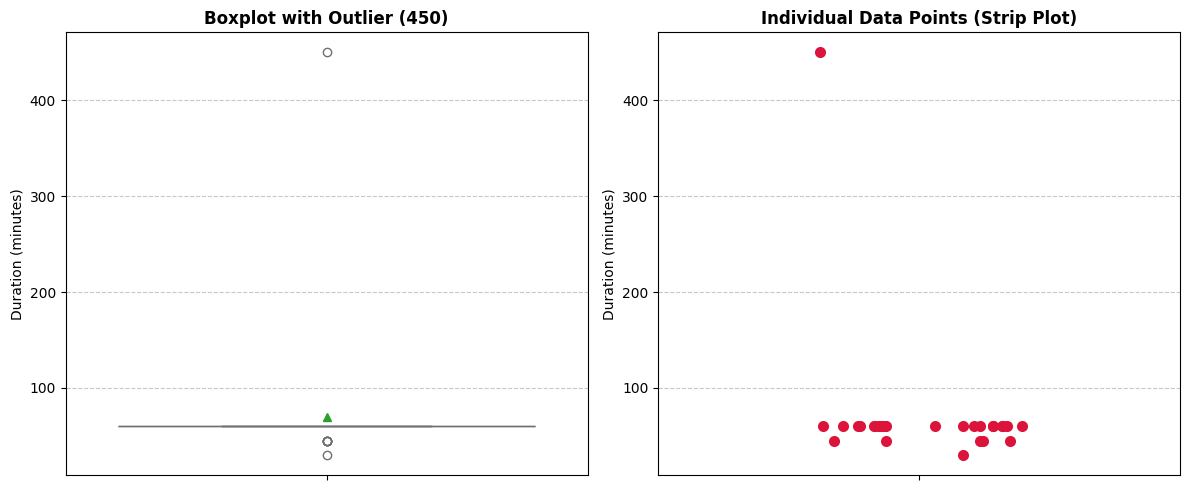

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['Duration'], ax=axes[0], color='skyblue', showmeans=True)
axes[0].set_title('Boxplot with Outlier (450)', fontweight='bold')
axes[0].set_ylabel('Duration (minutes)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.stripplot(y=df['Duration'], ax=axes[1], color='crimson', size=8, jitter=0.2)
axes[1].set_title('Individual Data Points (Strip Plot)', fontweight='bold')
axes[1].set_ylabel('Duration (minutes)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [56]:
clean_duration = df[df['Duration'] <= 120]['Duration']

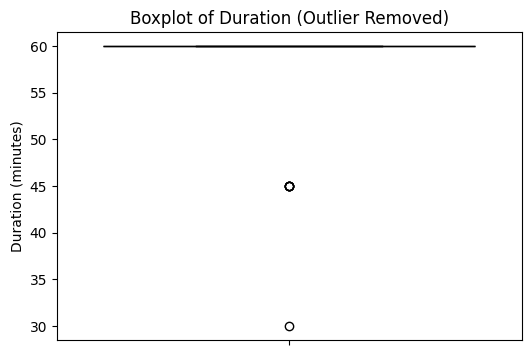

In [58]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=clean_duration, color='black')
plt.title('Boxplot of Duration (Outlier Removed)')
plt.ylabel('Duration (minutes)')
plt.show()